In [1]:
# ----------------------------
# Standard library
# ----------------------------
import json
import random
import os

# ----------------------------
# Core scientific stack
# ----------------------------
import numpy as np
import scipy.sparse as sp

# ----------------------------
# Visualization
# ----------------------------
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ----------------------------
# Progress / memory profiling
# ----------------------------
from tqdm import tqdm
import gc



In [2]:
# DISEASE_list = ['BIPOLAR','SCHIZOPHRENIA', 'LEUKEMIA', 'BREASTCANCER',"NONE"]
DISEASE_list = ['BIPOLAR','SCHIZOPHRENIA']

In [13]:
# Load D_avg_beta_array from the npy file
beta_list = [0.0, 0.001, 0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.35, 0.5, 0.7,0.8,0.9]
disease_avg_beta_dict = {}
disease_R_dict = {}

In [21]:
def compute_R_matrices(disease):
    R_matrix = []
    avg_beta_dict = {}
    OUTPUT_DIRECTORY = f"../output/{disease}/"
    D_baseline = np.load(OUTPUT_DIRECTORY + f"/beta_testing/dist_matrix_0.0.npy")
    D_baseline_avg = D_baseline.mean(axis=1)
    for beta in beta_list[1:]:
        D_beta = np.load(OUTPUT_DIRECTORY + f"/beta_testing/dist_matrix_{beta}.npy")
        D_beta_avg = D_beta.mean(axis=1)
        avg_beta_dict[beta] = D_beta_avg
        
        positive_vals = np.concatenate([D_baseline_avg, D_beta_avg]) 
        eps = 1e-8 * np.median(positive_vals)
        
        R = np.log10((D_beta_avg + eps) / (D_baseline_avg + eps))
        R_matrix.append(R)
    return avg_beta_dict, np.array(R_matrix)

In [22]:
for disease in DISEASE_list:
    disease_avg_beta_dict[disease], disease_R_dict[disease] = compute_R_matrices(disease)

In [23]:
# setting universal font sizes
font_size = 20
tick_font_size = 16
plt.rcParams.update({
    "font.size": font_size,          # base font size
    "axes.titlesize": font_size,
    "axes.labelsize": tick_font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": 14,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


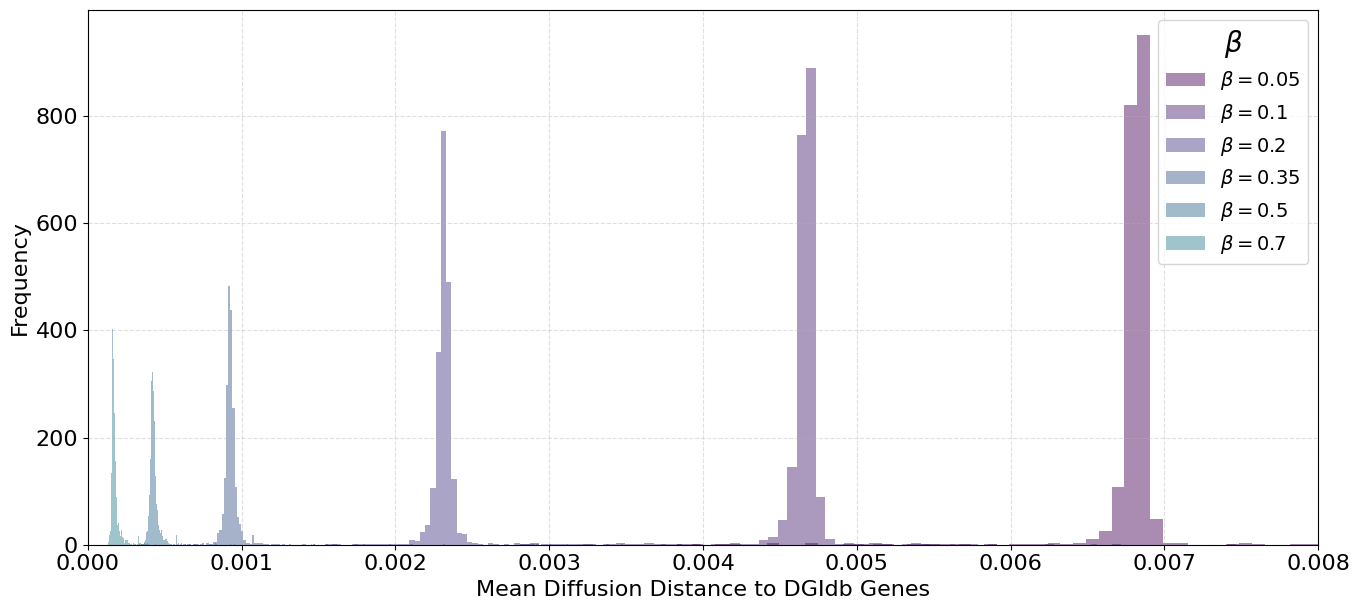

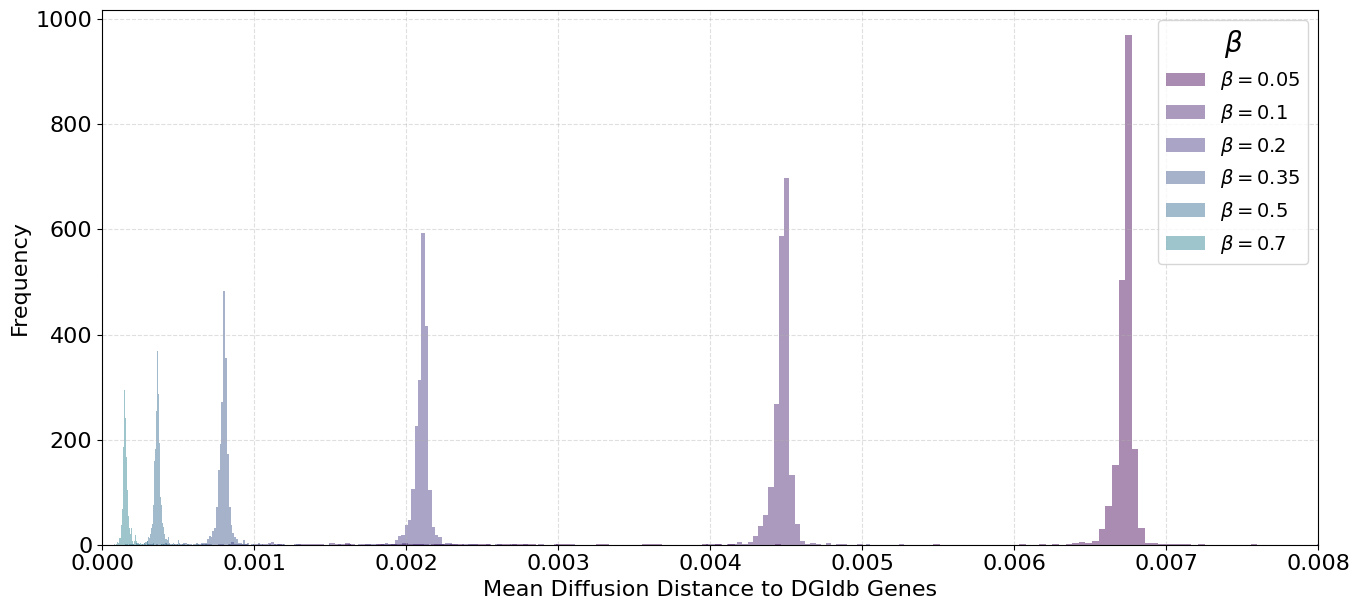

In [10]:
for disease in DISEASE_list:
    colors = plt.cm.viridis(np.linspace(0, 1, len(beta_list)))  # ADDED: one color per beta

    plt.figure(figsize=(14, 6.5))

    for i, beta in enumerate(beta_list[5:-2]):
        plt.hist(
            disease_avg_beta_dict[disease][beta],      # MODIFIED: values for this beta
            bins=200,             # ADDED: histogram bin count
            color=colors[i],     # ADDED: unique color for this beta
            alpha=0.45,          # ADDED: transparency so overlaps are visible
            label=fr"$\beta={beta}$"
        )

    plt.xlabel("Mean Diffusion Distance to DGIdb Genes")  # MODIFIED: replace with your x-axis label
    plt.ylabel("Frequency")  # MODIFIED: replace with your y-axis label

    # cap x-axis to 0.01
    plt.xlim(0, 0.008)
    plt.legend(title=r"$\beta$")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"../../Graphs/{disease}/diffusion_distance_distribution_comparison.pdf", dpi=300)
    plt.show()
    plt.close()

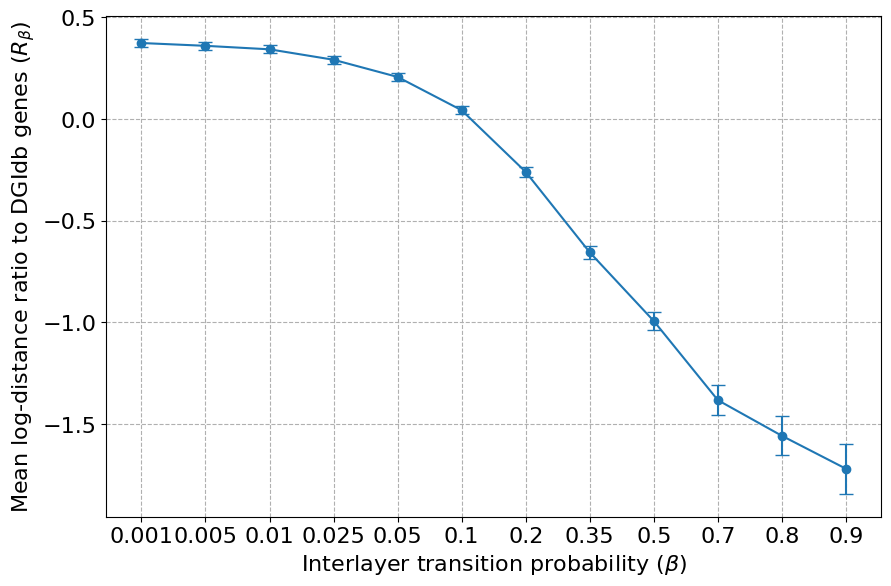

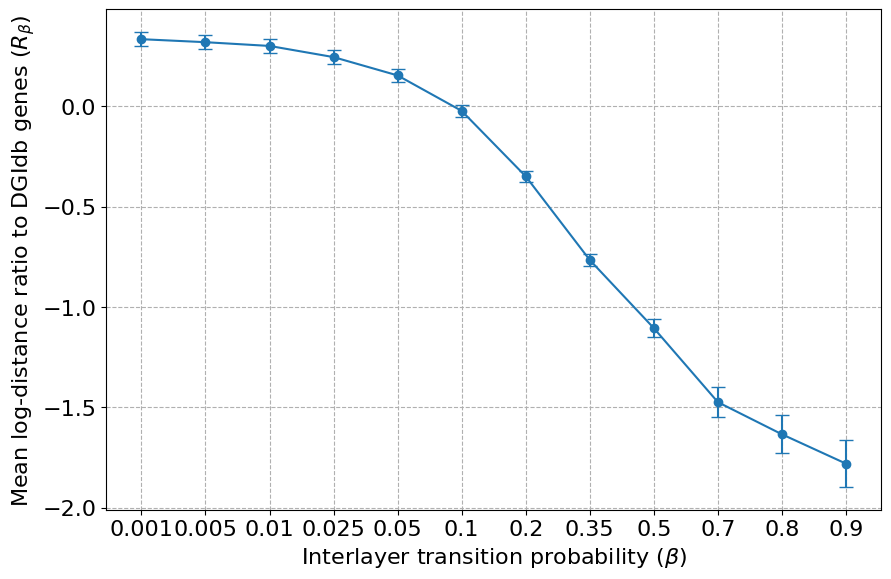

In [25]:
for disease in DISEASE_list:
    # Plot mean and standard deviation of R for each beta
    R_matrix = disease_R_dict[disease]

    mean_R = R_matrix.mean(axis=1)
    median_R = np.median(R_matrix, axis=1)

    std_R = R_matrix.std(axis=1)

    # # ADDED: compute sample size per beta
    # num_sample = R_matrix.shape[1]

    # # ADDED: compute standard error
    # se_R = std_R / np.sqrt(num_sample)

    x_pos = np.arange(len(beta_list[1:]))

    plt.figure(figsize=(10, 6.5))

    # USE STANDARD ERROR instead of std
    plt.errorbar(x_pos, mean_R, yerr=std_R, fmt='o-', capsize=5)

    plt.xlabel(r"Interlayer transition probability ($\beta$)")
    plt.ylabel(r"Mean log-distance ratio to DGIdb genes ($R_{\beta}$)")

    plt.xticks(x_pos, [str(b) for b in beta_list[1:]])

    plt.grid(True, which="both", ls="--")

    plt.savefig(f"../../Graphs/{disease}/beta_sensitivity.pdf", dpi=300)
    plt.show()
    plt.close()